# Notebook de Integrante 4

## Proyecto 2026 – Funciones y Análisis Ambiental con Pandas

Universidad de Cundinamarca


## 1. Objetivo

Procesar, visualizar y analizar los datos de temperatura y humedad obtenidos durante el monitoreo del sistema de compostaje, comparando las condiciones del compost, el invernadero y el ambiente exterior para identificar patrones de comportamiento, tendencias temporales y posibles efectos de las condiciones ambientales sobre el proceso de descomposición de la materia orgánica.


## 2. Importación de librerías


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 3. Carga de datos

Aquí se carga el archivo ubicado en la carpeta `data`.


In [12]:
df = pd.read_excel("../data/datos_compost.xlsx")

df["Fecha_Hora"] = pd.to_datetime(df["Fecha_Hora"])

df = df.sort_values("Fecha_Hora")

df.head()

,Fecha_Hora,Temp_Invernadero,Humedad_Invernadero,Temp_Exterior,Humedad_Exterior,Temp_Compost,Humedad_Compost
2472,2026-05-14 01:33:13,14.1,94.0,13.3,96.0,16.69,94.0
2471,2026-05-14 01:34:22,14.0,95.0,13.3,96.0,16.69,95.0
2470,2026-05-14 01:35:40,14.1,95.0,13.3,96.0,16.69,95.0
2469,2026-05-14 01:36:57,14.4,95.0,13.3,97.0,16.69,95.0
2468,2026-05-14 01:36:57,14.4,95.0,13.3,97.0,16.69,95.0


# Comparación Ambiental
## Compost - Invernadero - Exterior

In [13]:
def diferencias_temperatura(df):

    df["Dif_Compost_Exterior"] = (
        df["Temp_Compost"] -
        df["Temp_Exterior"]
    )

    df["Dif_Compost_Invernadero"] = (
        df["Temp_Compost"] -
        df["Temp_Invernadero"]
    )

    return df

In [14]:
df = diferencias_temperatura(df)

df.head()

,Fecha_Hora,Temp_Invernadero,Humedad_Invernadero,Temp_Exterior,Humedad_Exterior,Temp_Compost,Humedad_Compost,Dif_Compost_Exterior,Dif_Compost_Invernadero
2472,2026-05-14 01:33:13,14.1,94.0,13.3,96.0,16.69,94.0,3.39,2.59
2471,2026-05-14 01:34:22,14.0,95.0,13.3,96.0,16.69,95.0,3.39,2.69
2470,2026-05-14 01:35:40,14.1,95.0,13.3,96.0,16.69,95.0,3.39,2.59
2469,2026-05-14 01:36:57,14.4,95.0,13.3,97.0,16.69,95.0,3.39,2.29
2468,2026-05-14 01:36:57,14.4,95.0,13.3,97.0,16.69,95.0,3.39,2.29


In [15]:
print("Promedio Compost")

print(df["Temp_Compost"].mean())

print("Promedio Invernadero")

print(df["Temp_Invernadero"].mean())

print("Promedio Exterior")

print(df["Temp_Exterior"].mean())

Promedio Compost
16.784642135058633
Promedio Invernadero
20.273392640517592
Promedio Exterior
19.12341285887586


## 4. Gráficas

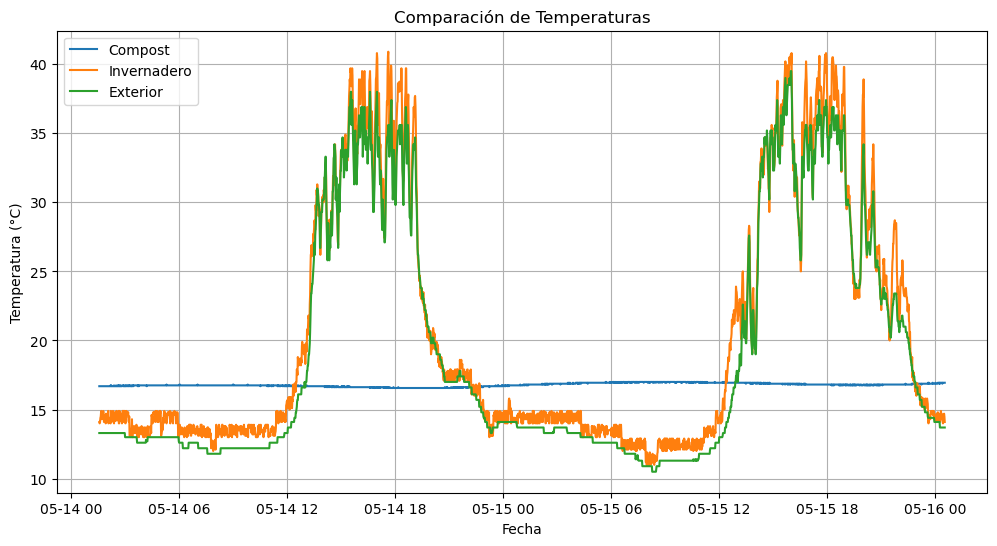

In [16]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Fecha_Hora"],
    df["Temp_Compost"],
    label="Compost"
)

plt.plot(
    df["Fecha_Hora"],
    df["Temp_Invernadero"],
    label="Invernadero"
)

plt.plot(
    df["Fecha_Hora"],
    df["Temp_Exterior"],
    label="Exterior"
)

plt.title("Comparación de Temperaturas")

plt.xlabel("Fecha")

plt.ylabel("Temperatura (°C)")

plt.legend()

plt.grid(True)

plt.show()

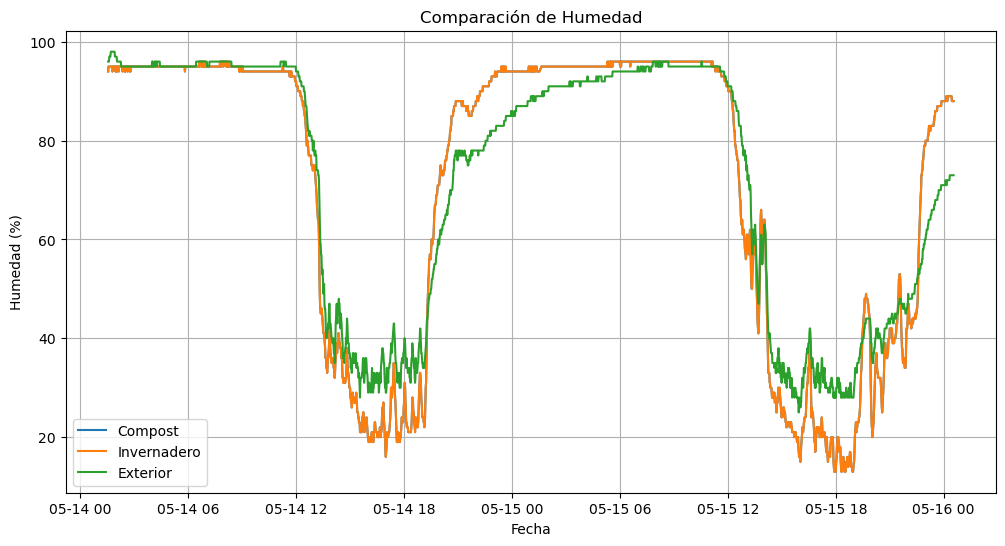

In [18]:
plt.figure(figsize=(12,6))

plt.plot(
    df["Fecha_Hora"],
    df["Humedad_Compost"],
    label="Compost"
)

plt.plot(
    df["Fecha_Hora"],
    df["Humedad_Invernadero"],
    label="Invernadero"
)

plt.plot(
    df["Fecha_Hora"],
    df["Humedad_Exterior"],
    label="Exterior"
)

plt.title("Comparación de Humedad")

plt.xlabel("Fecha")

plt.ylabel("Humedad (%)")

plt.legend()

plt.grid(True)

plt.show()

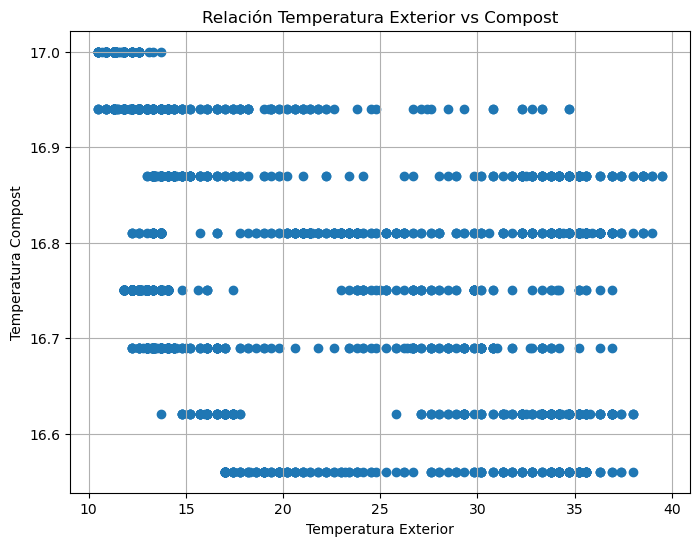

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["Temp_Exterior"],
    df["Temp_Compost"]
)

plt.xlabel("Temperatura Exterior")

plt.ylabel("Temperatura Compost")

plt.title(
    "Relación Temperatura Exterior vs Compost"
)

plt.grid(True)

plt.show()

## 5. Análisis de datos



In [ ]:


## Análisis de la temperatura

La temperatura del invernadero presentó las mayores variaciones durante el período de monitoreo, alcanzando valores cercanos a 40 °C. Este comportamiento se debe al efecto de acumulación de calor generado por la radiación solar, que queda retenida dentro de la estructura del invernadero y produce un aumento significativo de la temperatura interna.

La temperatura exterior mostró una tendencia similar a la observada en el invernadero, aunque con valores ligeramente inferiores debido a la circulación natural del aire y a la ausencia de una cubierta que retenga el calor. Los máximos de temperatura se registraron durante las horas de mayor radiación solar, mientras que los mínimos ocurrieron durante la noche y las primeras horas de la mañana.

Por otro lado, la temperatura del compost permaneció relativamente estable durante todo el período de estudio, con valores cercanos a 16-17 °C. Esta estabilidad sugiere una baja generación de calor metabólico por parte de los microorganismos o una posible etapa avanzada de estabilización del material orgánico, donde la actividad biológica disminuye considerablemente.

Las diferencias observadas entre el compost, el invernadero y el ambiente exterior evidencian que las condiciones climáticas tuvieron una mayor influencia sobre las variables monitoreadas que el propio proceso biológico del compostaje.

## Análisis de la humedad

La humedad relativa presentó un comportamiento inversamente proporcional a la temperatura. Durante los periodos en los que la temperatura aumentó, especialmente dentro del invernadero, la humedad disminuyó considerablemente, alcanzando valores inferiores al 30 %.

En el invernadero se registraron las mayores fluctuaciones de humedad, debido al incremento de temperatura generado por el confinamiento del calor. Este fenómeno favorece la disminución de la humedad relativa del aire, ya que el aire caliente tiene una mayor capacidad para contener vapor de agua.

La humedad exterior también disminuyó durante las horas de máxima radiación solar; sin embargo, las variaciones fueron menos pronunciadas debido a la ventilación natural y al intercambio constante de aire con el entorno.

La humedad asociada al compost se mantuvo más estable que las demás variables ambientales, indicando una mayor capacidad de retención de agua por parte del material orgánico y una menor sensibilidad a las fluctuaciones ambientales externas.

## Relación entre temperatura y humedad

Los resultados muestran una relación inversa claramente definida entre temperatura y humedad relativa. Cuando la temperatura aumentó durante las horas de mayor radiación solar, la humedad relativa disminuyó, mientras que durante los periodos de enfriamiento se observó una recuperación de los niveles de humedad.

Este comportamiento es consistente con los principios físicos de la atmósfera y permite identificar la influencia de las condiciones ambientales sobre los procesos asociados al compostaje y al funcionamiento del invernadero.


## 6. Conclusiones

Escribir aquí las conclusiones.




1. El invernadero registró las temperaturas más altas durante el monitoreo, alcanzando valores cercanos a 40 °C, lo que demuestra su capacidad para modificar las condiciones microclimáticas mediante la retención de calor.

2. La temperatura exterior siguió un comportamiento similar al del invernadero, aunque con menores valores máximos debido a la ventilación natural y a la ausencia de una estructura de confinamiento térmico.

3. La temperatura del compost permaneció relativamente constante durante el periodo evaluado, lo que sugiere una baja actividad microbiológica o una fase avanzada de estabilización del proceso de compostaje.

4. La humedad relativa presentó una relación inversa con la temperatura, disminuyendo durante las horas de mayor calentamiento y aumentando nuevamente cuando las temperaturas descendieron.

5. Las mayores variaciones de humedad se registraron en el invernadero, evidenciando la influencia del incremento de temperatura sobre la capacidad del aire para retener vapor de agua.

6. Los resultados obtenidos demuestran la importancia del monitoreo simultáneo de temperatura y humedad para evaluar las condiciones ambientales y su influencia sobre los procesos biológicos asociados al compostaje.

7. El análisis comparativo entre compost, invernadero y ambiente exterior permitió identificar que las condiciones climáticas tuvieron una influencia significativa sobre las variables medidas, especialmente sobre la temperatura y la humedad relativa.